In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [2]:
nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [3]:
nav.info()

<class 'pandas.DataFrame'>
RangeIndex: 46000 entries, 0 to 45999
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   amfi_code  46000 non-null  int64  
 1   date       46000 non-null  str    
 2   nav        46000 non-null  float64
dtypes: float64(1), int64(1), str(1)
memory usage: 1.1 MB


In [4]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

nav.head()

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [6]:
nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

nav.head(10)

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210
5,100016,2022-01-10,510.7136,-0.008639
6,100016,2022-01-11,513.5542,0.005562
7,100016,2022-01-12,512.3195,-0.002404
8,100016,2022-01-13,510.2445,-0.004050
9,100016,2022-01-14,514.3636,0.008073


In [7]:
var95 = (
    nav.groupby("amfi_code")["daily_return"]
       .quantile(0.05)
       .reset_index()
)

var95.columns = ["amfi_code", "VaR_95"]

var95.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [8]:
cvar = (
    nav.groupby("amfi_code")
       .apply(
           lambda x: x.loc[
               x["daily_return"] <= x["daily_return"].quantile(0.05),
               "daily_return"
           ].mean()
       )
       .reset_index(name="CVaR")
)

cvar.head()

,amfi_code,CVaR
0,100016,-0.018060
1,100025,-0.004994
2,100033,-0.023456
3,101206,-0.017439
4,101207,-0.032459


In [9]:
risk_report = var95.merge(cvar, on="amfi_code")

risk_report.head()

,amfi_code,VaR_95,CVaR
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [10]:
risk_report.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

print("Saved Successfully!")

Saved Successfully!


In [11]:
# Rolling 90-day Sharpe Ratio

nav["rolling_mean"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(90).mean())
)

nav["rolling_std"] = (
    nav.groupby("amfi_code")["daily_return"]
       .transform(lambda x: x.rolling(90).std())
)

nav["rolling_sharpe"] = (
    nav["rolling_mean"] /
    nav["rolling_std"]
) * np.sqrt(252)

nav.head()

,amfi_code,date,nav,daily_return,rolling_mean,rolling_std,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN,NaN,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN,NaN,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN,NaN,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN,NaN,NaN


In [12]:
top5 = (
    nav.groupby("amfi_code")["nav"]
       .last()
       .sort_values(ascending=False)
       .head(5)
       .index
)

top5

Index([120844, 125497, 101206, 149322, 100016], dtype='int64', name='amfi_code')

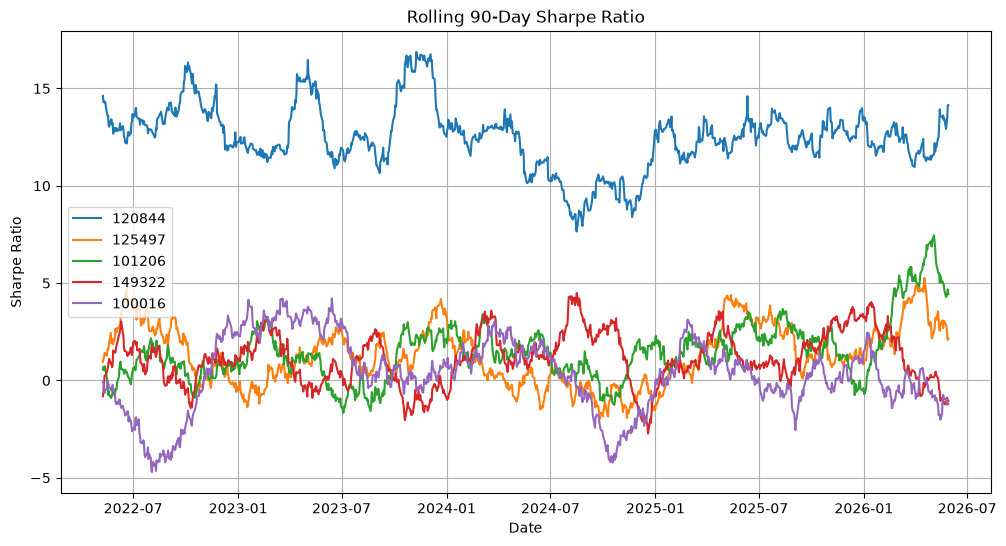

In [13]:
plt.figure(figsize=(12,6))

for fund in top5:
    temp = nav[nav["amfi_code"] == fund]
    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        label=str(fund)
    )

plt.title("Rolling 90-Day Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()
plt.grid(True)

plt.savefig(
    "../reports/rolling_sharpe_chart.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [15]:
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [16]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 32778 entries, 0 to 32777
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   investor_id         32778 non-null  str    
 1   transaction_date    32778 non-null  str    
 2   amfi_code           32778 non-null  int64  
 3   transaction_type    32778 non-null  str    
 4   amount_inr          32778 non-null  int64  
 5   state               32778 non-null  str    
 6   city                32778 non-null  str    
 7   city_tier           32778 non-null  str    
 8   age_group           32778 non-null  str    
 9   gender              32778 non-null  str    
 10  annual_income_lakh  32778 non-null  float64
 11  payment_mode        32778 non-null  str    
 12  kyc_status          32778 non-null  str    
dtypes: float64(1), int64(2), str(10)
memory usage: 3.3 MB


In [17]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [18]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [19]:
sip_avg = (
    transactions[
        transactions["transaction_type"] == "SIP"
    ]
    .groupby("age_group")["amount_inr"]
    .mean()
    .reset_index(name="avg_sip_amount")
)

sip_avg

,age_group,avg_sip_amount
0,18-25,10953.073245
1,26-35,10986.895696
2,36-45,10885.758628
3,46-55,11136.763478
4,56+,11574.922192


In [20]:
total_investment = (
    transactions
    .groupby("age_group")["amount_inr"]
    .sum()
    .reset_index(name="total_invested")
)

total_investment

,age_group,total_invested
0,18-25,531639392
1,26-35,1451600218
2,36-45,871647528
3,46-55,405406469
4,56+,261286823


In [21]:
top_fund = (
    transactions
    .groupby(["age_group","amfi_code"])
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund
    .sort_values(
        ["age_group","count"],
        ascending=[True, False]
    )
    .drop_duplicates("age_group")
)

top_fund

,age_group,amfi_code,count
16,18-25,119094,145
73,26-35,125498,383
115,36-45,148568,238
133,46-55,118636,111
194,56+,148567,78


In [22]:
cohort = (
    sip_avg
    .merge(total_investment,on="age_group")
    .merge(
        top_fund[["age_group","amfi_code"]],
        on="age_group"
    )
)

cohortcohort = (
    sip_avg
    .merge(total_investment,on="age_group")
    .merge(
        top_fund[["age_group","amfi_code"]],
        on="age_group"
    )
)

cohort

,age_group,avg_sip_amount,total_invested,amfi_code
0,18-25,10953.073245,531639392,119094
1,26-35,10986.895696,1451600218,125498
2,36-45,10885.758628,871647528,148568
3,46-55,11136.763478,405406469,118636
4,56+,11574.922192,261286823,148567


In [23]:
cohort.to_csv(
    "../reports/investor_cohort_analysis.csv",
    index=False
)

print("Investor Cohort Analysis Saved!")

Investor Cohort Analysis Saved!


In [24]:
transactions["cohort_year"] = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .transform("min")
    .dt.year
)

In [25]:
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip.head()


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [26]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [27]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head(15)

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0
12652,INV000003,2024-07-16,101207,SIP,2676,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,NaN
27622,INV000003,2025-03-11,149322,SIP,15185,Gujarat,Ahmedabad,T30,26-35,Female,10.6,Mandate,Verified,2024,238.0
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0


In [28]:
eligible = (
    sip.groupby("investor_id")
       .filter(lambda x: len(x) >= 6)
)

eligible.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
4773,INV000004,2024-03-16,101208,SIP,960,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,NaN
6418,INV000004,2024-04-11,119095,SIP,20602,Punjab,Chandigarh,T30,26-35,Male,20.0,Net Banking,Verified,2024,26.0
8271,INV000004,2024-05-09,120844,SIP,541,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,28.0
12003,INV000004,2024-07-07,148569,SIP,9761,Punjab,Chandigarh,T30,26-35,Male,20.0,UPI,Verified,2024,59.0
28749,INV000004,2025-03-29,149324,SIP,14282,Punjab,Chandigarh,T30,26-35,Male,20.0,Mandate,Verified,2024,265.0


In [29]:
avg_gap = (
    eligible.groupby("investor_id")["gap_days"]
            .mean()
            .reset_index(name="avg_gap_days")
)

avg_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [30]:
avg_gap["risk_status"] = np.where(
    avg_gap["avg_gap_days"] > 35,
    "At Risk",
    "Regular"
)

avg_gap.head()

,investor_id,avg_gap_days,risk_status
0,INV000004,85.400000,At Risk
1,INV000008,70.400000,At Risk
2,INV000010,64.800000,At Risk
3,INV000011,40.166667,At Risk
4,INV000012,57.000000,At Risk


In [31]:
avg_gap.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved!")

SIP Continuity Report Saved!


In [32]:
holdings = pd.read_csv("../data/raw/09_portfolio_holdings.csv")

holdings.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31


In [33]:
holdings.info()

<class 'pandas.DataFrame'>
RangeIndex: 322 entries, 0 to 321
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   amfi_code          322 non-null    int64  
 1   stock_symbol       322 non-null    str    
 2   stock_name         322 non-null    str    
 3   sector             322 non-null    str    
 4   weight_pct         322 non-null    float64
 5   market_value_cr    322 non-null    float64
 6   current_price_inr  322 non-null    float64
 7   portfolio_date     322 non-null    str    
dtypes: float64(3), int64(1), str(4)
memory usage: 20.3 KB


In [34]:
holdings.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [35]:
# Sector HHI Concentration

sector_hhi = (
    holdings.groupby("sector")["weight_pct"]
    .apply(lambda x: ((x / x.sum()) ** 2).sum())
    .reset_index(name="HHI")
)

sector_hhi = sector_hhi.sort_values("HHI", ascending=False)

sector_hhi.head()

,sector,HHI
3,Consumer Goods,0.121619
10,Paints,0.118779
12,Telecom,0.111780
9,NBFC,0.107005
2,Cement,0.103260


In [36]:
sector_hhi.to_csv(
    "../reports/sector_hhi_report.csv",
    index=False
)

print("Sector HHI Report Saved!")

Sector HHI Report Saved!


# Advanced Business Insights

### 1. Lowest Risk Funds
Funds with the least negative VaR and CVaR demonstrate greater downside stability, making them suitable for conservative investors.

### 2. Rolling Sharpe Performance
Certain funds consistently maintained higher rolling Sharpe Ratios over the analysis period, indicating superior risk-adjusted returns.

### 3. Portfolio Concentration
The HHI analysis shows that sectors like Banking and Pharma have higher concentration across portfolios, indicating greater sector exposure.

### 4. Investor Behaviour
Investors with consistent SIP investments tend to accumulate wealth more steadily compared to irregular investors.

### 5. Fund Recommendation
Based on VaR and CVaR, conservative investors are recommended funds with the lowest downside risk, while higher-risk investors can select funds with higher return potential.

In [37]:
# SIP Transactions Only

sip = transactions[transactions["transaction_type"] == "SIP"].copy()

sip["transaction_date"] = pd.to_datetime(sip["transaction_date"])

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [38]:
sip_count = sip.groupby("investor_id").size()

eligible = sip_count[sip_count >= 6].index

sip = sip[sip["investor_id"].isin(eligible)]

print("Eligible Investors:", sip["investor_id"].nunique())

Eligible Investors: 1362


In [39]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

In [40]:
sip_gap = (
    sip.groupby("investor_id")["gap_days"]
       .mean()
       .reset_index()
)

sip_gap.rename(
    columns={"gap_days":"avg_gap_days"},
    inplace=True
)

sip_gap.head()

,investor_id,avg_gap_days
0,INV000004,85.400000
1,INV000008,70.400000
2,INV000010,64.800000
3,INV000011,40.166667
4,INV000012,57.000000


In [41]:
sip_gap["status"] = sip_gap["avg_gap_days"].apply(
    lambda x: "At-Risk" if x > 35 else "Healthy"
)

sip_gap.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


In [42]:
sip_gap.to_csv(
    "../reports/sip_continuity_report.csv",
    index=False
)

print("SIP Continuity Report Saved!")

SIP Continuity Report Saved!
